# BookWise — E-Commerce Book Pricing & Rating Analytics

## 04. Exploratory Data Analysis & Visualization

### Objective
To explore and visualize book pricing, ratings, categories, availability, stock levels, and other important attributes to identify meaningful patterns and business insights.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

### Load the Cleaned Dataset

In [3]:
df = pd.read_csv("../data/cleaned_books.csv")

df.head()

,Title,Price,Rating,Availability,Link,Category,Description,UPC,Product Type,Tax,Number Available,Number of Reviews,Stock_Quantity,Rating_Category,Title_Length,Description_Length,Description_Word_Count,Price_Band,Stock_Status
0,A Light in the Attic,51.77,3,In stock,a-light-in-the-attic_1000/index.html,Poetry,It's hard to imagine a world without A Light i...,a897fe39b1053632,Books,0.0,In stock (22 available),0,22,Average,20,1017,164,Premium,High Stock
1,Tipping the Velvet,53.74,1,In stock,tipping-the-velvet_999/index.html,Historical Fiction,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,Books,0.0,In stock (20 available),0,20,Low,18,1029,165,Premium,High Stock
2,Soumission,50.10,1,In stock,soumission_998/index.html,Fiction,"Dans une France assez proche de la nôtre, un h...",6957f44c3847a760,Books,0.0,In stock (20 available),0,20,Low,10,1093,163,Premium,High Stock
3,Sharp Objects,47.82,4,In stock,sharp-objects_997/index.html,Mystery,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48,Books,0.0,In stock (20 available),0,20,High,13,1635,274,Premium,High Stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,sapiens-a-brief-history-of-humankind_996/index...,History,From a renowned historian comes a groundbreaki...,4165285e1663650f,Books,0.0,In stock (20 available),0,20,High,37,1945,304,Premium,High Stock


In [4]:
df.shape

(1000, 19)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Title                   1000 non-null   str    
 1   Price                   1000 non-null   float64
 2   Rating                  1000 non-null   int64  
 3   Availability            1000 non-null   str    
 4   Link                    1000 non-null   str    
 5   Category                1000 non-null   str    
 6   Description             1000 non-null   str    
 7   UPC                     1000 non-null   str    
 8   Product Type            1000 non-null   str    
 9   Tax                     1000 non-null   float64
 10  Number Available        1000 non-null   str    
 11  Number of Reviews       1000 non-null   int64  
 12  Stock_Quantity          1000 non-null   int64  
 13  Rating_Category         1000 non-null   str    
 14  Title_Length            1000 non-null   int64  
 15 

In [6]:
df.describe()

,Price,Rating,Tax,Number of Reviews,Stock_Quantity,Title_Length,Description_Length,Description_Word_Count
count,1000.00000,1000.000000,1000.0,1000.0,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.07035,2.923000,0.0,0.0,8.585000,39.097000,1431.678000,236.381000
std,14.44669,1.434967,0.0,0.0,5.654622,25.752724,669.218167,107.551267
min,10.00000,1.000000,0.0,0.0,1.000000,2.000000,25.000000,3.000000
25%,22.10750,2.000000,0.0,0.0,3.000000,19.000000,1069.750000,177.000000
50%,35.98000,3.000000,0.0,0.0,7.000000,35.000000,1348.500000,222.500000
75%,47.45750,4.000000,0.0,0.0,14.000000,53.000000,1681.500000,279.000000
max,59.99000,5.000000,0.0,0.0,22.000000,204.000000,8646.000000,1390.000000


### Price Distribution

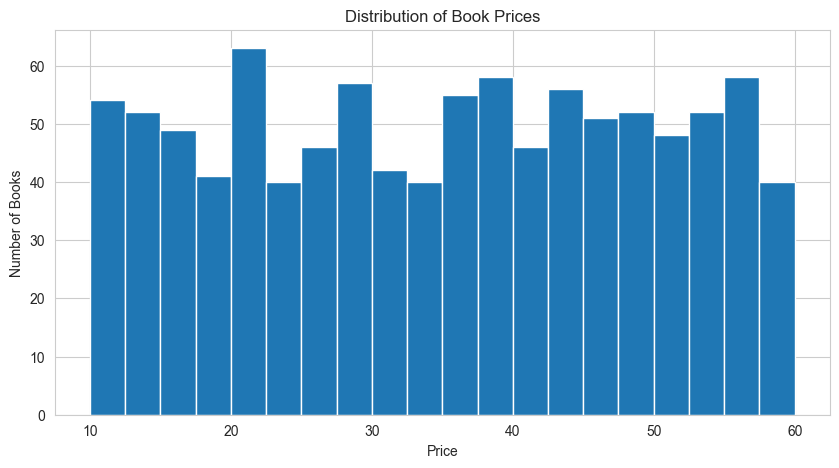

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(df["Price"], bins=20)

plt.title("Distribution of Book Prices")
plt.xlabel("Price")
plt.ylabel("Number of Books")

plt.savefig("01_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Rating Distribution

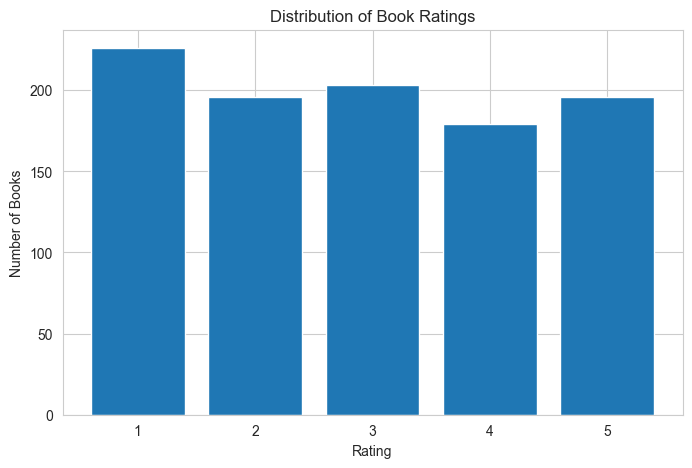

In [9]:
rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks([1, 2, 3, 4, 5])

plt.savefig("02_rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Price Band Distribution

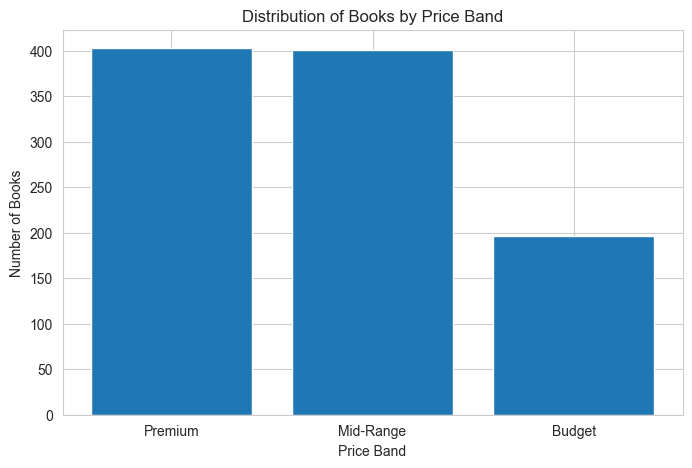

In [10]:
price_band_counts = df["Price_Band"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(price_band_counts.index, price_band_counts.values)

plt.title("Distribution of Books by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Number of Books")

plt.savefig("03_price_band_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Rating Category Distribution

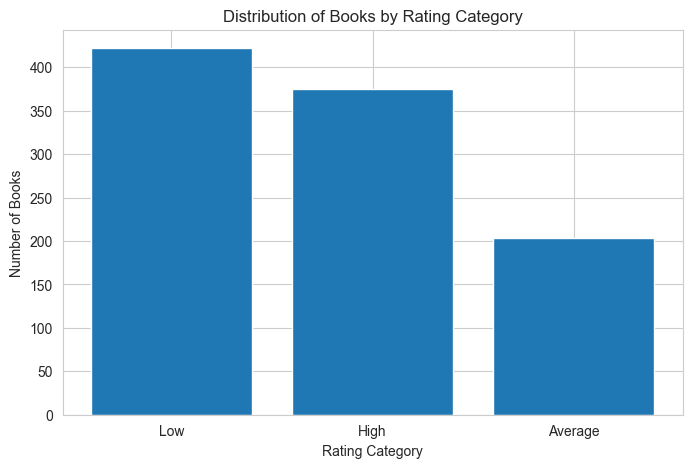

In [11]:
rating_category_counts = df["Rating_Category"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(rating_category_counts.index, rating_category_counts.values)

plt.title("Distribution of Books by Rating Category")
plt.xlabel("Rating Category")
plt.ylabel("Number of Books")

plt.savefig("04_rating_category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Stock Status Distribution

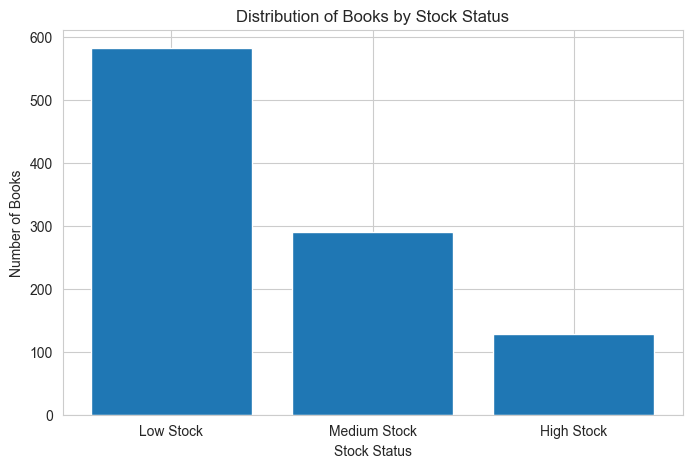

In [12]:
stock_status_counts = df["Stock_Status"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(stock_status_counts.index, stock_status_counts.values)

plt.title("Distribution of Books by Stock Status")
plt.xlabel("Stock Status")
plt.ylabel("Number of Books")

plt.savefig("05_stock_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Category Distribution

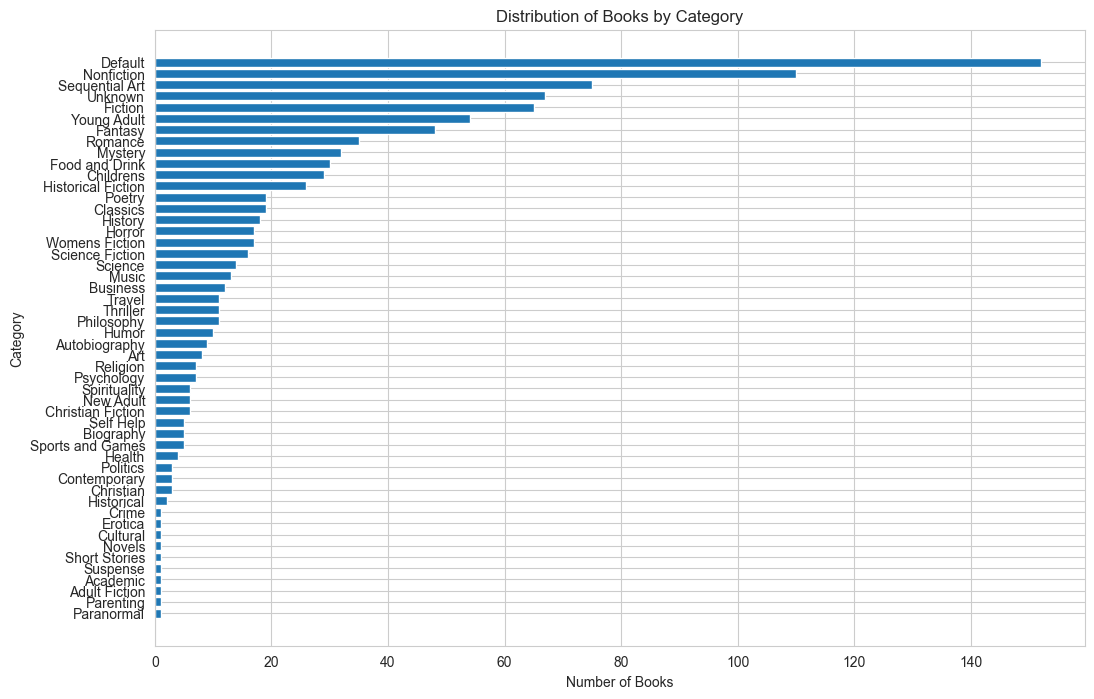

In [13]:
category_counts = df["Category"].value_counts()

plt.figure(figsize=(12, 8))

plt.barh(category_counts.index, category_counts.values)

plt.title("Distribution of Books by Category")
plt.xlabel("Number of Books")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.savefig("06_category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Price vs Rating

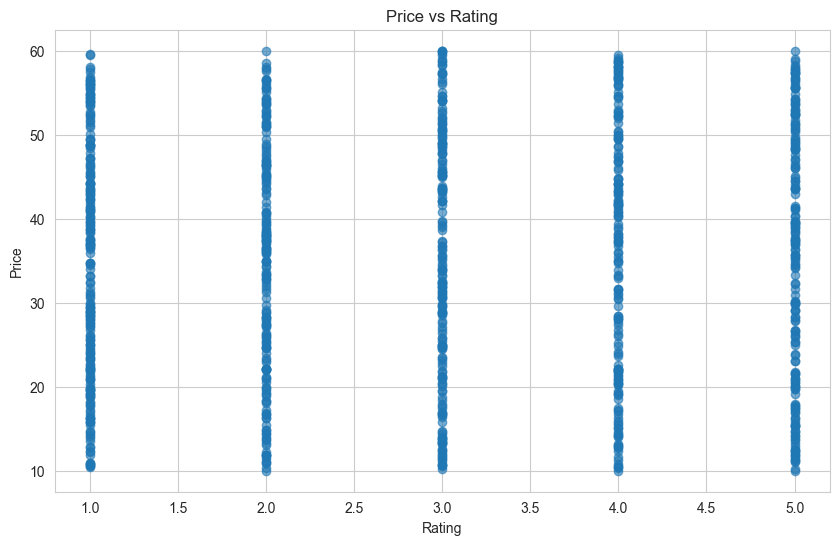

In [14]:
plt.figure(figsize=(10, 6))

plt.scatter(df["Rating"], df["Price"], alpha=0.6)

plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price")

plt.savefig("07_price_vs_rating.png", dpi=300, bbox_inches="tight")
plt.show()

### Average Book Price by Category

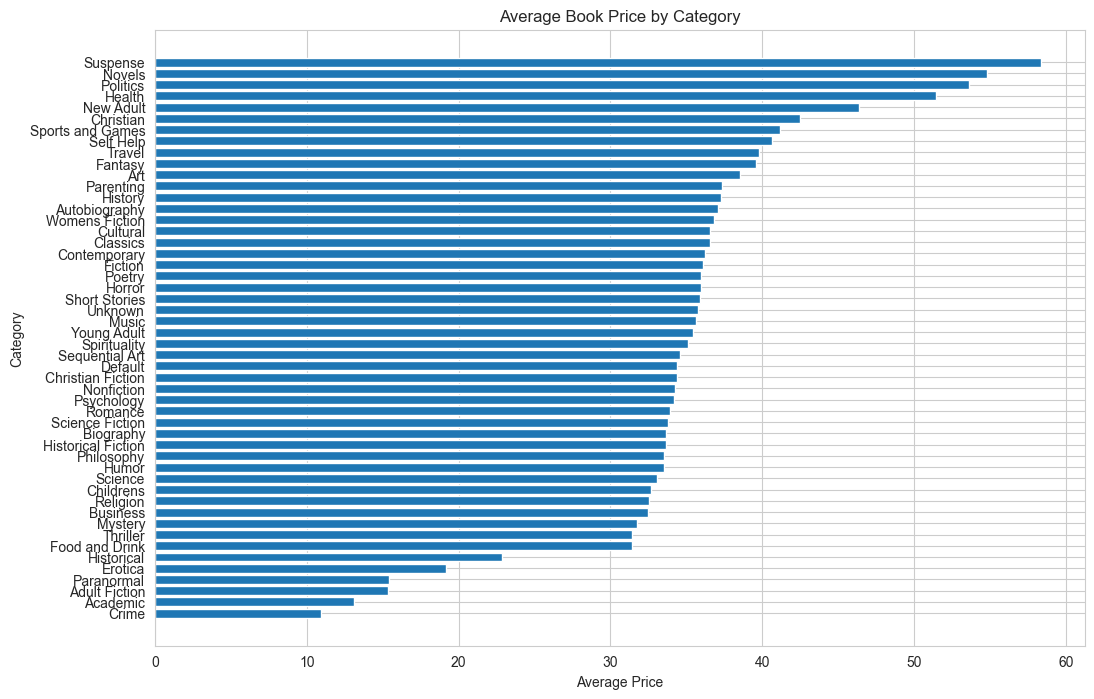

In [15]:
avg_price_category = df.groupby("Category")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))

plt.barh(avg_price_category.index, avg_price_category.values)

plt.title("Average Book Price by Category")
plt.xlabel("Average Price")
plt.ylabel("Category")

plt.gca().invert_yaxis()

plt.savefig("08_average_price_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

### Average Book Rating by Category

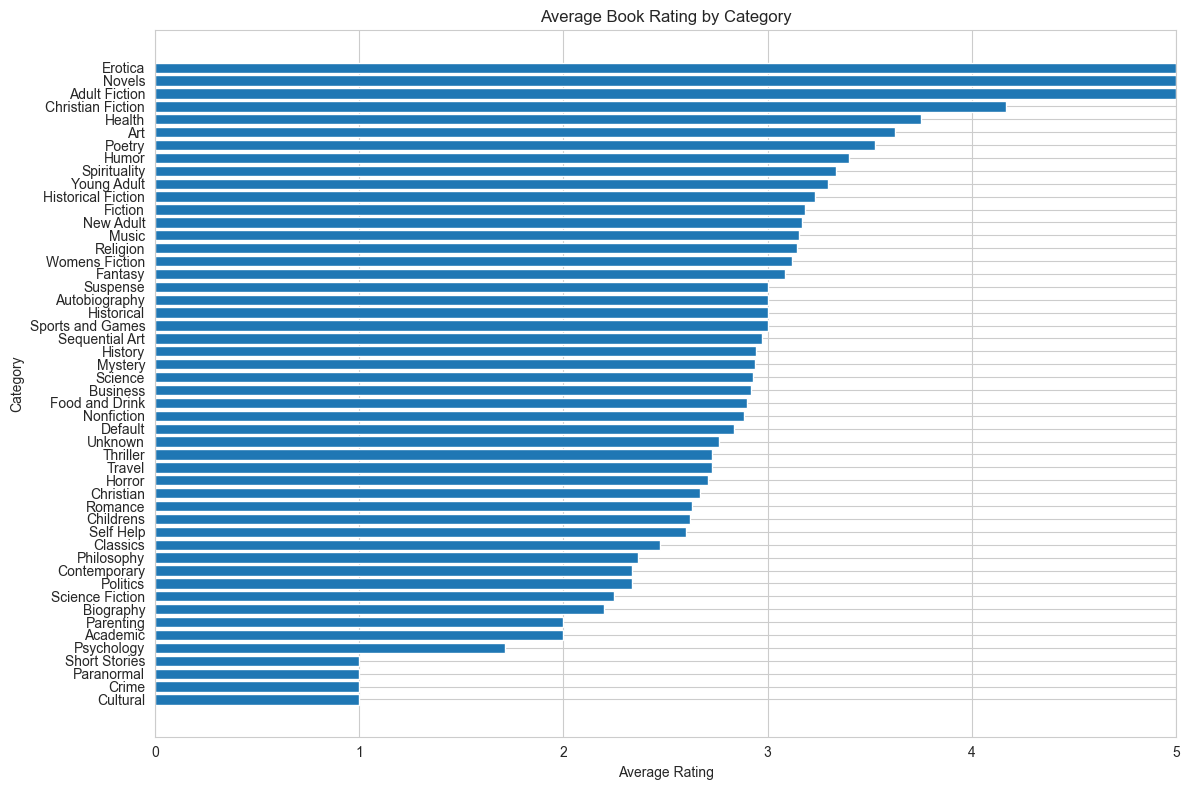

In [16]:
avg_rating_category = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 8))

plt.barh(avg_rating_category.index, avg_rating_category.values)

plt.title("Average Book Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.xlim(0, 5)

plt.tight_layout()

plt.savefig("09_average_rating_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

### Average Stock Quantity by Price Band

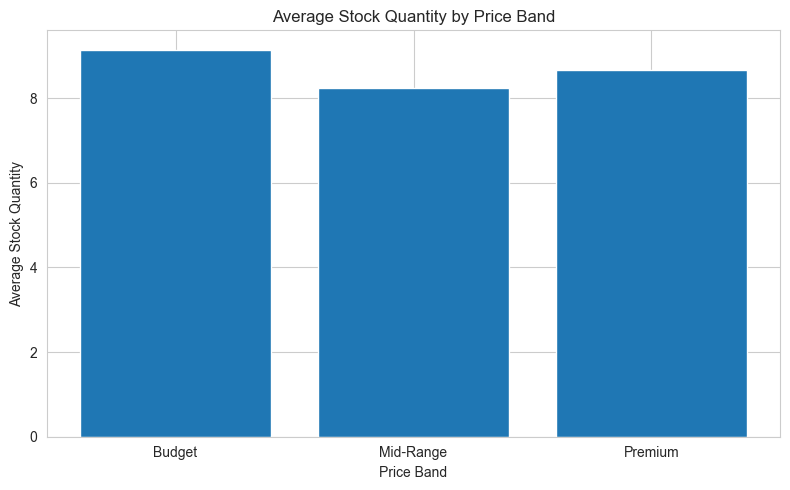

In [17]:
avg_stock_price_band = (
    df.groupby("Price_Band")["Stock_Quantity"]
    .mean()
    .reindex(["Budget", "Mid-Range", "Premium"])
)

plt.figure(figsize=(8, 5))

plt.bar(avg_stock_price_band.index, avg_stock_price_band.values)

plt.title("Average Stock Quantity by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Average Stock Quantity")

plt.tight_layout()

plt.savefig("10_average_stock_by_price_band.png", dpi=300, bbox_inches="tight")
plt.show()

### Average Stock Quantity by Rating

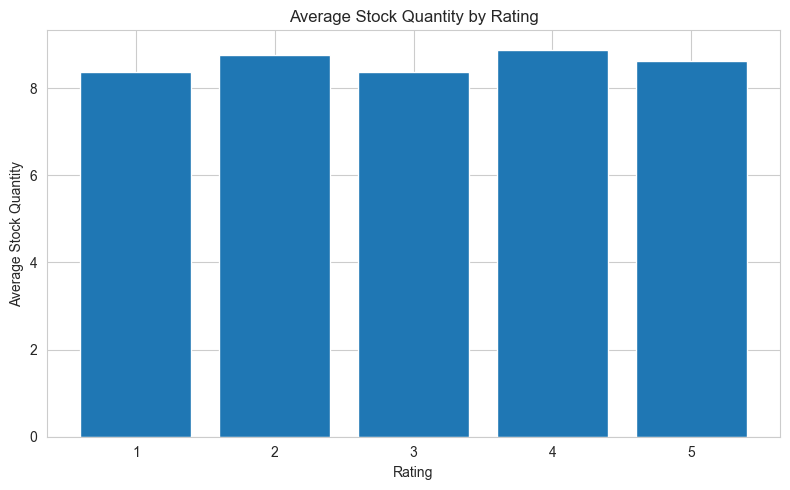

In [18]:
avg_stock_rating = (
    df.groupby("Rating")["Stock_Quantity"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(avg_stock_rating.index, avg_stock_rating.values)

plt.title("Average Stock Quantity by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Stock Quantity")
plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()

plt.savefig("11_average_stock_by_rating.png", dpi=300, bbox_inches="tight")
plt.show()

### Average Book Price by Rating Category

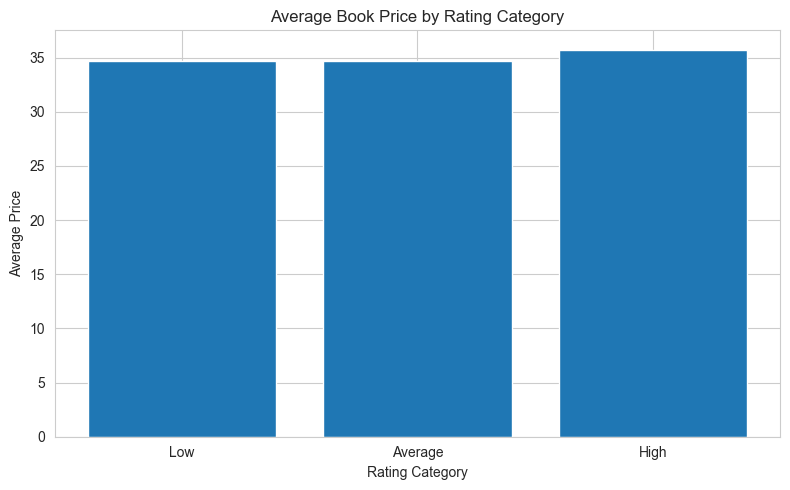

In [19]:
avg_price_rating_category = (
    df.groupby("Rating_Category")["Price"]
    .mean()
    .reindex(["Low", "Average", "High"])
)

plt.figure(figsize=(8, 5))

plt.bar(
    avg_price_rating_category.index,
    avg_price_rating_category.values
)

plt.title("Average Book Price by Rating Category")
plt.xlabel("Rating Category")
plt.ylabel("Average Price")

plt.tight_layout()

plt.savefig("12_average_price_by_rating_category.png", dpi=300, bbox_inches="tight")
plt.show()

### Average Book Price by Stock Status

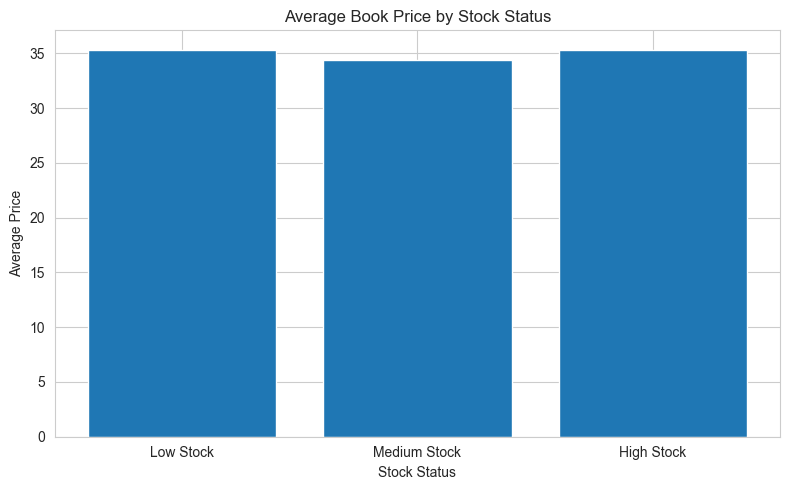

In [20]:
avg_price_stock_status = (
    df.groupby("Stock_Status")["Price"]
    .mean()
    .reindex(["Low Stock", "Medium Stock", "High Stock"])
)

plt.figure(figsize=(8, 5))

plt.bar(
    avg_price_stock_status.index,
    avg_price_stock_status.values
)

plt.title("Average Book Price by Stock Status")
plt.xlabel("Stock Status")
plt.ylabel("Average Price")

plt.tight_layout()

plt.savefig("13_average_price_by_stock_status.png", dpi=300, bbox_inches="tight")
plt.show()

### Average Stock Quantity by Category

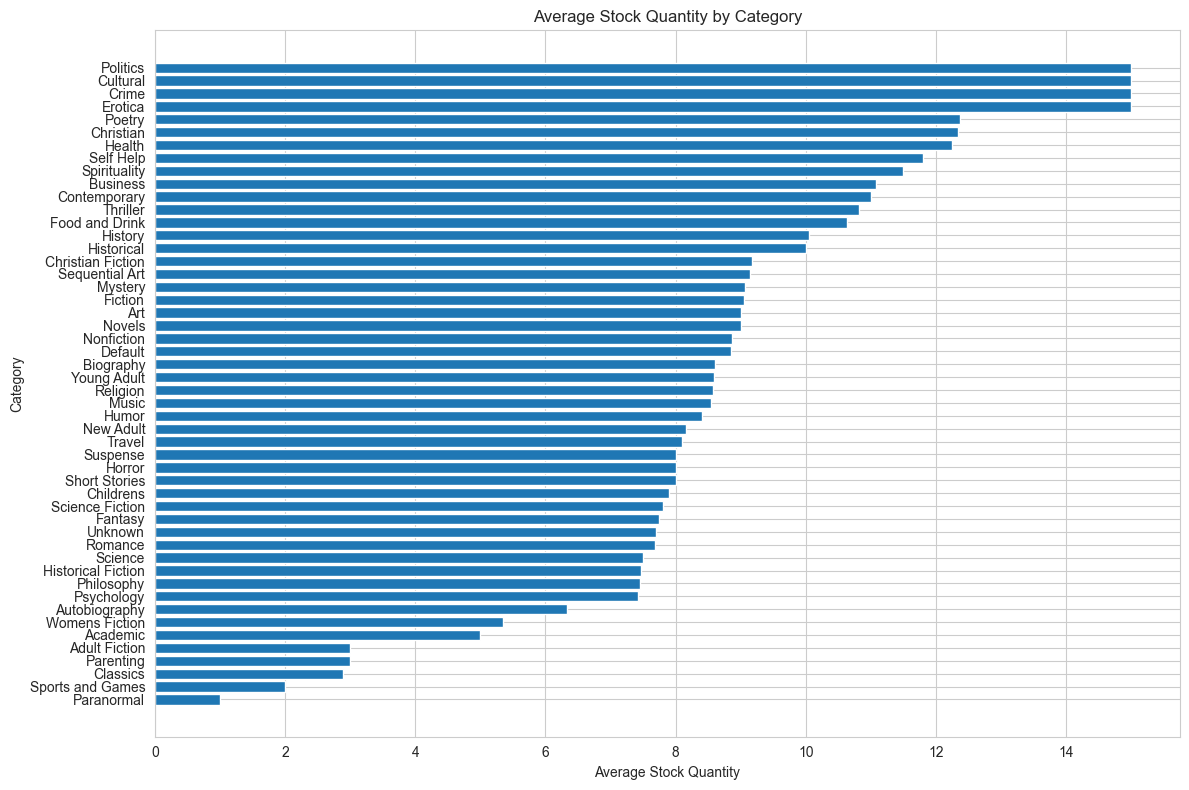

In [21]:
avg_stock_category = (
    df.groupby("Category")["Stock_Quantity"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 8))

plt.barh(
    avg_stock_category.index,
    avg_stock_category.values
)

plt.title("Average Stock Quantity by Category")
plt.xlabel("Average Stock Quantity")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig("14_average_stock_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

### Average Book Rating by Price Band

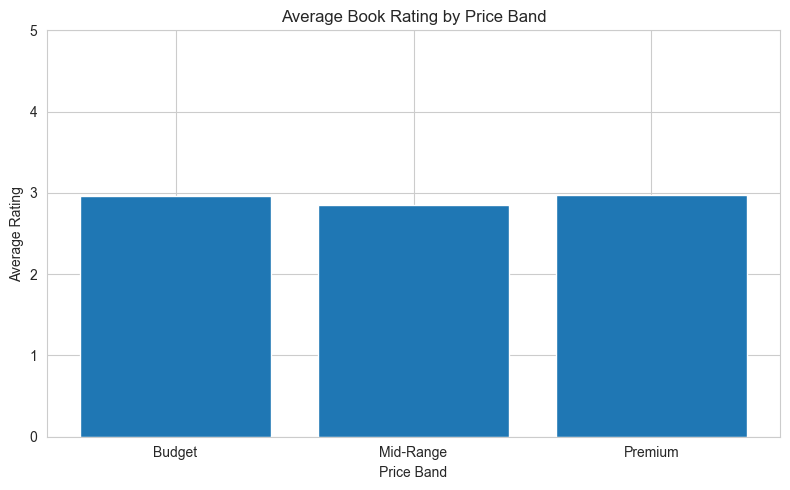

In [22]:
avg_rating_price_band = (
    df.groupby("Price_Band")["Rating"]
    .mean()
    .reindex(["Budget", "Mid-Range", "Premium"])
)

plt.figure(figsize=(8, 5))

plt.bar(
    avg_rating_price_band.index,
    avg_rating_price_band.values
)

plt.title("Average Book Rating by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Average Rating")

plt.ylim(0, 5)

plt.tight_layout()

plt.savefig("15_average_rating_by_price_band.png", dpi=300, bbox_inches="tight")
plt.show()

### Stock Quantity Distribution

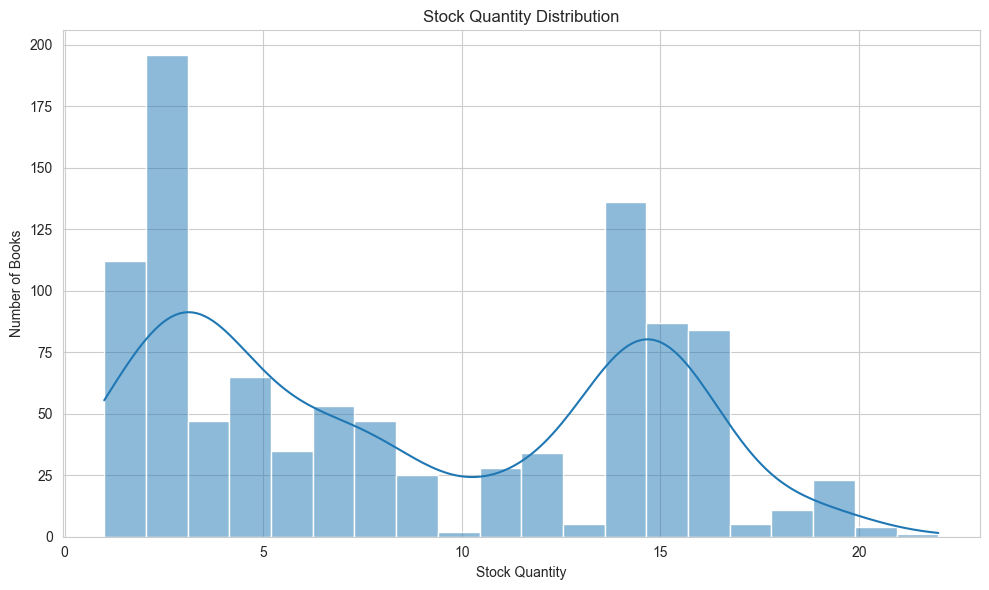

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Stock_Quantity"],
    bins=20,
    kde=True
)

plt.title("Stock Quantity Distribution")
plt.xlabel("Stock Quantity")
plt.ylabel("Number of Books")
plt.tight_layout()

os.makedirs("eda_charts", exist_ok=True)

plt.savefig(
    "16_stock_quantity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Price Distribution by Price Band


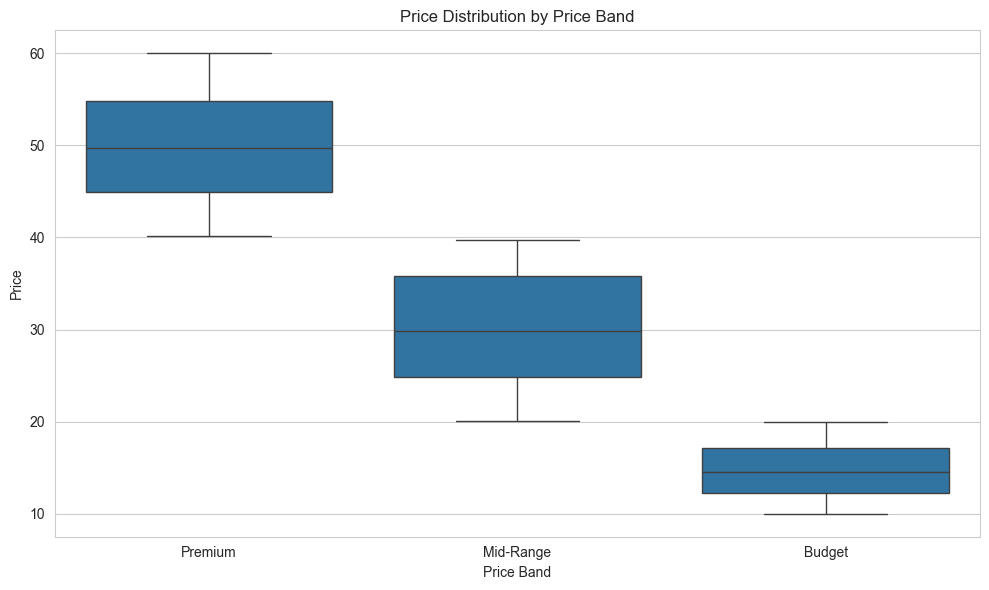

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Price_Band",
    y="Price"
)

plt.title("Price Distribution by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Price")
plt.tight_layout()

plt.savefig(
    "17_price_distribution_by_price_band.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Stock Quantity by Rating Category

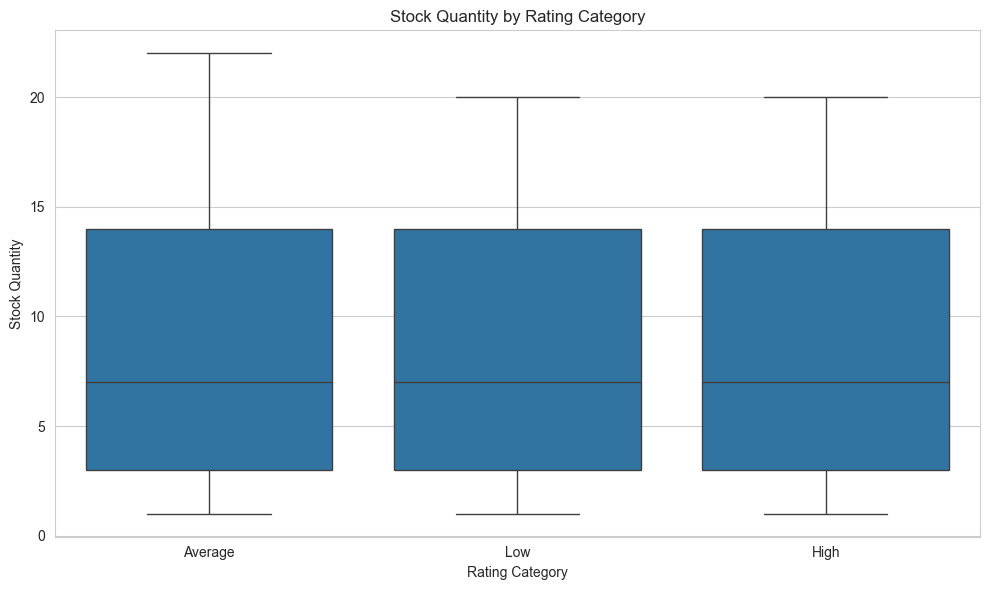

In [25]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Rating_Category",
    y="Stock_Quantity"
)

plt.title("Stock Quantity by Rating Category")
plt.xlabel("Rating Category")
plt.ylabel("Stock Quantity")
plt.tight_layout()

plt.savefig(
    "18_stock_quantity_by_rating_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Top 10 Most Expensive Books

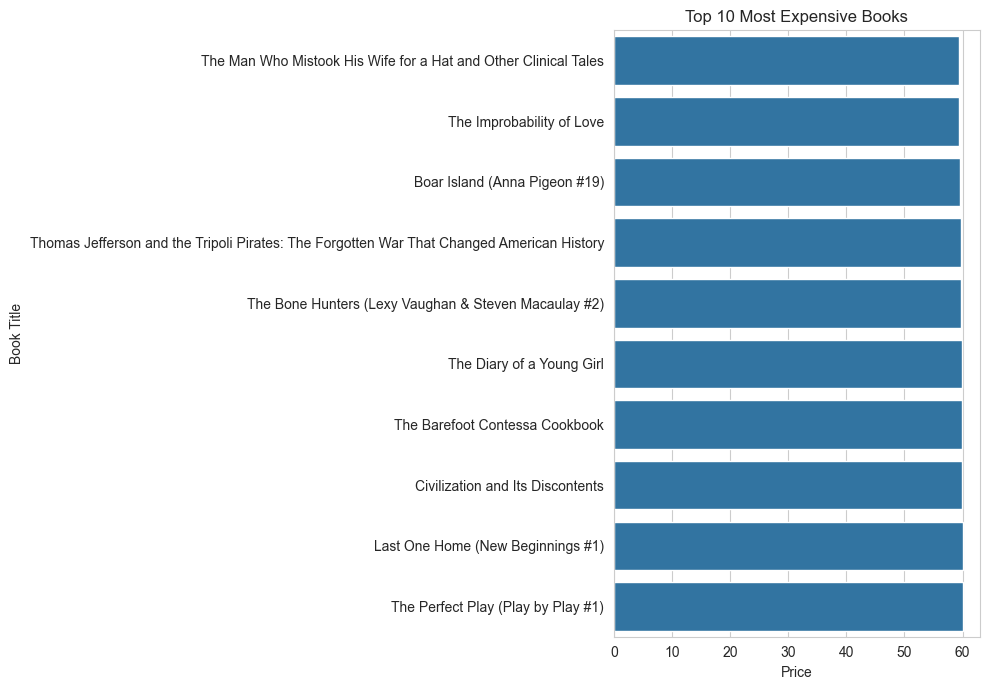

In [26]:
top_10_expensive = (
    df.nlargest(10, "Price")
      .sort_values("Price", ascending=True)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_10_expensive,
    x="Price",
    y="Title"
)

plt.title("Top 10 Most Expensive Books")
plt.xlabel("Price")
plt.ylabel("Book Title")
plt.tight_layout()

plt.savefig(
    "../charts/19_top_10_most_expensive_books.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Outliner Analysis

In [27]:
outlier_features = [
    "Price",
    "Stock_Quantity",
    "Number of Reviews",
    "Description_Word_Count"
]

outlier_summary = []

for column in outlier_features:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (df[column] < lower) |
        (df[column] > upper)
    ).sum()

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Feature,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count
0,Price,22.1075,47.4575,-15.9175,85.4825,0
1,Stock_Quantity,3.0000,14.0000,-13.5000,30.5000,0
2,Number of Reviews,0.0000,0.0000,0.0000,0.0000,0
3,Description_Word_Count,177.0000,279.0000,24.0000,432.0000,45


## Conclusion

Exploratory Data Analysis was performed on the cleaned BookWise dataset to understand the distribution and relationships among book price, rating, stock quantity, categories, price bands, and rating categories.

A total of 19 visualizations were created using distribution plots, bar charts, scatter plots, and box plots.

The analysis helped identify important patterns in book pricing, ratings, inventory levels, category distribution, and relationships between different book characteristics.

The visual findings provide the foundation for the business insights and recommendations presented later in the project and will also be incorporated into the interactive Power BI dashboard.